<a href="https://colab.research.google.com/github/simar-rekhi/triton/blob/main/vectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thread Launching & Block Processing
imagine having two vectors A and B, each of size 50k. In Triton, we aim to deal with such space concerns by using block sizes. You get the same output as if SM was looking at one partition of size block_size specifically.


Say, in this 60k vector, we have each block of size 8k. So total parallel threads needed will be [60//8 + 1] to process the data simulataneously.
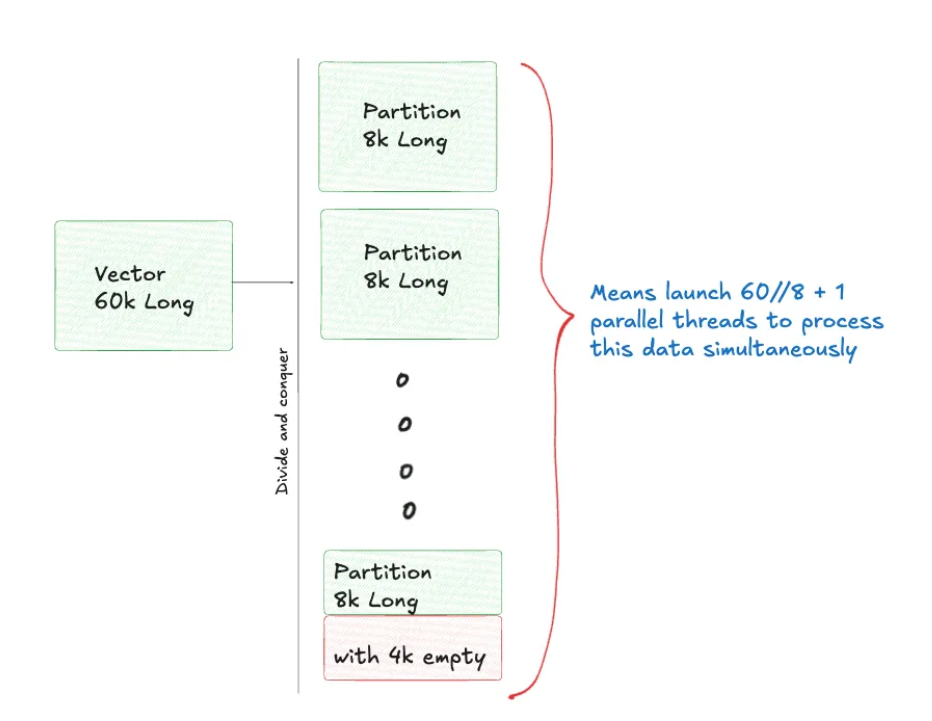




In [1]:
!nvidia-smi
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
import torch
import triton
import triton.language as tl
print(torch.cuda.is_available())

Sat Nov 15 18:47:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import triton
import triton.language as tl

#tell the compiler that transform this python snippet into a kernel instance
@triton.jit

def add_kernel(x, y, output, n_elements, BLOCK_SIZE: tl.constexpr):
  # this gets shared across the many process in the launch grid
  pid = tl.program(axis=0)

  # first thread should be able to look at the data from [0:1024]
  block_start = pid*BLOCK_SIZE
  offsets = block_start = tl.arrange(0, BLOCK_SIZE)

  # the way we prevent out-of-bounds accesses is by creating a mask
  # here, OOB is our 4k in the last offset
  mask = offsets < n_elements

  # load x and y from DRAM, masking out any extra elements in case the input is not a multiple of BLOCK_SIZE
  x = tl.load_size(x + offsets, mask = mask)
  y = tl.load_size(y + offsets, mask = mask)
  oput = x + y

  # write x and y back to DRAM
  tl.store(output + offsets, oput, mask=mask)



def add(x: torch.Tensor, y:torch.Tensor, BLOCK_SIZE: int = 1024):
  # preallocate output
  output = torch.empty_like(x)
  assert x.device == DEVICE and y.device == DEVICE and output.device == DEVICE
  n_elements = output.numel()

  # the launch grid gives info about the number of parallel threads that should be generated
  grid = (triton.cdvivup(n_elements, BLOCK_SIZE),)

  # call the kernel
  add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE)
  return output